In [122]:
import xarray as xr
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

In [123]:
array = np.zeros((3, 3))
Q_array= array.copy()

In [124]:
Q_array[0, 0] = 1
Q_array[0, 1] = 2
Q_array[0, 2] = 1
Q_array[1, 0] = 1
Q_array[1, 1] = 3
Q_array[1, 2] = 4
Q_array[2, 0] = 2
Q_array[2, 1] = 3
Q_array[2, 2] = 7
Q_array 

array([[1., 2., 1.],
       [1., 3., 4.],
       [2., 3., 7.]])

In [125]:
ID_array = np.zeros((3, 3), dtype = int)
ID_array[0, 0] = 1
ID_array[0, 1] = 2
ID_array[0, 2] = 3
ID_array[1, 0] = 4
ID_array[1, 1] = 5
ID_array[1, 2] = 6
ID_array[2, 0] = 7
ID_array[2, 1] = 8
ID_array[2, 2] = 9
ID_array


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [126]:
outID_array = np.zeros((3, 3), dtype = int)
outID_array[0, 0] = 2
outID_array[0, 1] = 5
outID_array[0, 2] = 6
outID_array[1, 0] = 7
outID_array[1, 1] = 6
outID_array[1, 2] = 9
outID_array[2, 0] = 8
outID_array[2, 1] = 9
outID_array[2, 2] = -1
outID_array

array([[ 2,  5,  6],
       [ 7,  6,  9],
       [ 8,  9, -1]])

In [127]:
inID_array = np.zeros((3, 3), dtype= object)
inID_array[0, 0] = np.nan
inID_array[0, 1] = 1
inID_array[0, 2] = np.nan
inID_array[1, 0] = np.nan
inID_array[1, 1] = 2
inID_array[1, 2] = (3, 5)
inID_array[2, 0] = 4
inID_array[2, 1] = 7
inID_array[2, 2] = (6, 8)
inID_array

array([[nan, 1, nan],
       [nan, 2, (3, 5)],
       [4, 7, (6, 8)]], dtype=object)

In [128]:
ore_array = np.zeros((3, 3), dtype= float)
H = 10
F = 0.01
ore_array[0, 0] = H * ((4 * 1000) / 4) * F * 27
ore_array

array([[2700.,    0.,    0.],
       [   0.,    0.,    0.],
       [   0.,    0.,    0.]])

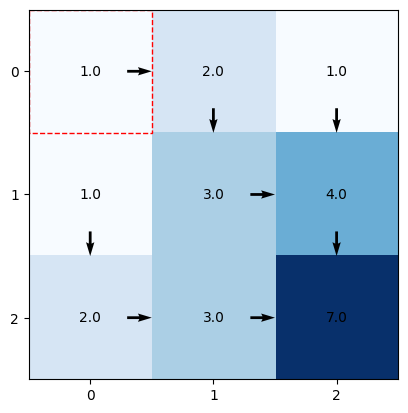

In [129]:
fig, ax = plt.subplots(1, 1)
for (i, j), value in np.ndenumerate(ID_array):
    ax.text(j, i, str(Q_array[i, j]), ha='center', va='center', color='black')


ax.imshow(Q_array, cmap= "Blues")
ax.set_xticks(np.arange(0, 3))
ax.set_yticks(np.arange(0, 3))
ax.set_xticklabels(np.arange(0, 3))
ax.set_yticklabels(np.arange(0, 3))

from matplotlib.patches import Rectangle


rect = Rectangle(
    (-0.5, -0.5),   
    1,              
    1,              
    linewidth=1,
    edgecolor='red',
    facecolor='none',
    linestyle = "--"
)

ax.add_patch(rect)
ax.quiver(0.3, 0, 1, 0, color='k', scale=5, scale_units='xy')
ax.quiver(1, 0.3, 0, -1, color='k', scale=5, scale_units='xy')
ax.quiver(2, 0.3, 0, -1, color = "k", scale = 5, scale_units = "xy")
ax.quiver(0, 1.3, 0, -1, color = "k", scale = 5, scale_units = "xy")
ax.quiver(1.3, 1, 1, 0, color = "k", scale = 5, scale_units = "xy")
ax.quiver(2, 1.3, 0, -1, color = "k", scale = 5, scale_units = "xy")
ax.quiver(0.3, 2, 1, 0, color = "k", scale = 5, scale_units = "xy");
ax.quiver(1.3, 2, 1, 0, color = "k", scale = 5, scale_units = "xy");


In [130]:
ds = xr.DataArray(
    Q_array,
    dims=["i", "j"],
    attrs=dict(
        description="Streamflow per cell as yearly mean",
        units="m3/s",
    )
).to_dataset(name = "Q")

da_ID = xr.DataArray(
    ID_array,
    dims=["i", "j"],
    attrs=dict(
        description="Cell IDs",
        units="None"))

da_outID = xr.DataArray(
    outID_array,
    dims=["i", "j"],
    attrs=dict(
        description="Outflow cell IDs",
        units="None"))

da_inID = xr.DataArray(
    inID_array,
    dims=["i", "j"],
    attrs=dict(
        description="Inflow cell IDs",
        units="None"))

da_ore = xr.DataArray(
    ore_array,
    dims=["i", "j"],
    attrs=dict(
        description="ore content",
        units="None"))


In [131]:
ds["ID"] = da_ID
ds["outID"] = da_outID
ds["inID"] = da_inID
ds["ore"] = da_ore
ds = ds.assign_coords(i=np.arange(3), j=np.arange(3))

In [132]:
ds

<xarray.Dataset> Size: 408B
Dimensions:  (i: 3, j: 3)
Coordinates:
  * i        (i) int64 24B 0 1 2
  * j        (j) int64 24B 0 1 2
Data variables:
    Q        (i, j) float64 72B 1.0 2.0 1.0 1.0 3.0 4.0 2.0 3.0 7.0
    ID       (i, j) int64 72B 1 2 3 4 5 6 7 8 9
    outID    (i, j) int64 72B 2 5 6 7 6 9 8 9 -1
    inID     (i, j) object 72B nan 1 nan nan 2 (3, 5) 4 7 (6, 8)
    ore      (i, j) float64 72B 2.7e+03 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

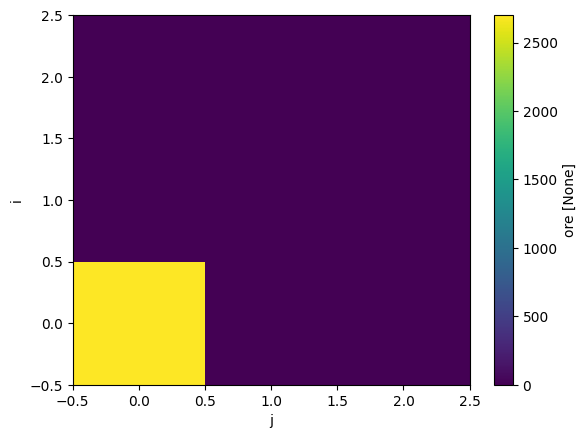

In [133]:
ax = ds["ore"].plot()

In [134]:
months = pd.date_range("2025-01-01", periods = 12, freq="MS")
ds_monthly = ds.expand_dims(time = months)
ds_monthly["Q"] = ds_monthly["Q"] / 12

In [135]:

sys.getsizeof(ds)

120

In [193]:
class Model:

    def __init__(self, dataset, t_unit, do = 10, h_plus = 1e-7):
        self.dataset = dataset.copy(deep=True)
        self.t_unit = t_unit
        self.time_steps = self.dataset["time"]
        self.do = do
        self.h_plus = h_plus

        self.dataset = self.dataset.assign(ferrous_iron=xr.full_like(self.dataset.Q, 0))
        self.dataset = self.dataset.assign(ferric_iron=xr.full_like(self.dataset.Q, 0))
        self.dataset = self.dataset.assign(sulphate=xr.full_like(self.dataset.Q, 0))
        self.dataset = self.dataset.assign(hydrogen_ion=xr.full_like(self.dataset.Q, 0))
        self.dataset = self.dataset.assign(iron_III_hydroxide=xr.full_like(self.dataset.Q, 0))

        attrs_dict = {
        'ferrous_iron': {'units': 'mol/timestep', 'description': 'Fe²⁺'},
        'ferric_iron': {'units': 'mol/timestep', 'description': 'Fe³⁺'},
        'sulphate': {'units': 'mol/timestep', 'description': 'SO₄²⁻'},
        'hydrogen_ion': {'units': 'mol/timestep', 'description': 'H⁺'},
        'iron_III_hydroxide': {'units': 'mol/timestep', 'description': 'Fe(OH)₃'}}

        for var_name, attrs in attrs_dict.items():
            self.dataset[var_name].attrs = attrs

        self.dataset = self.dataset.set_coords("ID")
        self.time_step_seconds = {"month": 2628000, "week" : 604800}[self.t_unit]
    def run(self):

        # get the most upstream cells (cells with no inflow)
        mask = xr.apply_ufunc(pd.isna, self.dataset["inID"], vectorize = True, dask = "parallelized", output_dtypes=[bool])
        mask_np = pd.isna(self.dataset["inID"].values)
        mask = xr.DataArray(mask_np, dims = self.dataset["inID"].dims, coords = self.dataset["inID"].coords)
        most_upstream = self.dataset.where(mask, drop = True)
        
        # get only most upstream cells where reactive ores are present
        mask_ores = most_upstream["ore"] > 0
        most_upstream_reactive_ores = most_upstream.where(mask_ores, drop=True)

        # start timestep t
        for ti, t in enumerate(self.time_steps.values):

            # add mass from previous timestep to current timestep
            if ti > 0:
                prev_t = self.time_steps.values[ti - 1]

                for var in ["ferrous_iron", "ferric_iron",
                            "hydrogen_ion", "sulphate",
                            "iron_III_hydroxide"]:
                    prev_vals = self.dataset[var].sel(time=prev_t).fillna(0)
                    #self.dataset[var].loc[dict(time=t)] += \
                        #self.dataset[var].sel(time=prev_t)
                    self.dataset[var].loc[dict(time=t)] = \
                        self.dataset[var].loc[dict(time=t)].fillna(0) + prev_vals
                    
            dataset_t = self.dataset.sel(time = t)
            
            if ti > 0:
                current_slice = dataset_t.where(dataset_t["ID"].isin(most_upstream_reactive_ores["ID"].values), drop = True)
            else:
                current_slice = most_upstream_reactive_ores.sel(time = t)

            # processing step of most upstream cells with water and reactive ores at t 
            # --------------------------------------------------------------------------------------------
                   
            # check for water > 0
            mask = current_slice["Q"] > 0
            current_slice = current_slice.where(mask, drop=True)

            current_slice = self.process_slice(current_slice)
            # Ensure we have a proper slice with dimensions
            if current_slice.sizes == {}:
                print(f"Warning: Empty slice at time {t}, skipping update")
                continue   # or return from the loop

            # Verify i and j are present as coordinates
            if 'i' not in current_slice.coords or 'j' not in current_slice.coords:
                current_slice = current_slice.set_coords(['i', 'j'])

            self.update_dataset(t, current_slice)
           # transport only the processed cells
            if ti < len(self.time_steps) - 1:
                self.transport(t, current_slice)

            # ----------------------------------------------------------------------------------------------

            # loop to process downstream cells until no more downstream cells exist
            #-----------------------------------------------------------------------------------------------
            while current_slice["ID"].size > 0:
                
                # get next current slice
                out_ids = current_slice["outID"].values
                out_ids = out_ids[out_ids != -1]

                current_slice = dataset_t.where(dataset_t["ID"].isin(out_ids), drop = True)
                
                # process current slice cells 
                mask = current_slice["Q"] > 0
                current_slice = current_slice.where(mask, drop=True)
                if current_slice.sizes == {}:
                    print(f"Warning: Empty slice at time {t}, skipping update")
                    continue   # or return from the loop

                # Verify i and j are present as coordinates
                if 'i' not in current_slice.coords or 'j' not in current_slice.coords:
                    current_slice = current_slice.set_coords(['i', 'j'])
                    
                self.update_dataset(t, current_slice)
                dataset_t = self.dataset.sel(time=t)
                if ti < len(self.time_steps) - 1:
                    self.transport(t, current_slice)
            # -----------------------------------------------------------------------------------------------

    def process_slice(self, current_slice):

        k = 10**-8.19
        do_term = self.do * 0.5
        h_background = self.h_plus

       
        # 1) pyrite oxidation by ferric iron 
        mask_ferric = (current_slice["ferric_iron"] > 0) & (current_slice["ore"] > 0)
        mask_rate = (current_slice["ore"] > 0) & (~mask_ferric)

        ferric_consumed = xr.where(
            mask_ferric,
            current_slice["ferric_iron"] * 1.07,
            0
        )

        ferrous_produced = ferric_consumed
        hydrogen_produced = xr.where(
            mask_ferric,
            current_slice["ferric_iron"] * 1.14,
            0
        )

        current_slice = current_slice.assign(
            ferric_iron=current_slice["ferric_iron"] - ferric_consumed,
            ferrous_iron=current_slice["ferrous_iron"] + ferrous_produced,
            hydrogen_ion=current_slice["hydrogen_ion"] + hydrogen_produced,
        )

        # 2) rate-limited pyrite oxidation 
        effective_h = xr.where(
            (current_slice["hydrogen_ion"] <= 0) | current_slice["hydrogen_ion"].isnull(),
            h_background,
            current_slice["hydrogen_ion"]
        )

        rate = k * do_term / (effective_h ** 0.01)

        reaction_amount = xr.where(
            mask_rate,
            rate * current_slice["ore"] * self.time_step_seconds,
            0
        )

        current_slice = current_slice.assign(
            ferrous_iron=current_slice["ferrous_iron"] + reaction_amount,
            sulphate=current_slice["sulphate"] + 2 * reaction_amount,
            hydrogen_ion=current_slice["hydrogen_ion"] + 2 * reaction_amount,
        )



        # 3) ferrous to ferric oxidation
        ferrous_available = current_slice["ferrous_iron"]
        current_slice = current_slice.assign(
            ferric_iron=current_slice["ferric_iron"] + ferrous_available,
            ferrous_iron=xr.zeros_like(current_slice["Q"]),   
            hydrogen_ion=current_slice["hydrogen_ion"] - 1 * ferrous_available,
        )

        # prevent negative hydrogen
        current_slice["hydrogen_ion"] = current_slice["hydrogen_ion"].clip(min=0)

        
        # 4) ferric <> iron III hydroxide equilibrium
        ferric = current_slice["ferric_iron"]
        hydroxide = current_slice["iron_III_hydroxide"]

        diff = ferric - hydroxide
        adjustment = 0.5 * diff

        current_slice = current_slice.assign(
            ferric_iron=ferric - adjustment,
            iron_III_hydroxide=hydroxide + adjustment,
        )


        # 5) numerical cleanup

        for var in ["ferrous_iron", "ferric_iron", "hydrogen_ion",
                    "sulphate", "iron_III_hydroxide"]:
            current_slice[var] = current_slice[var].fillna(0)
            current_slice[var] = current_slice[var].clip(min=0)

        return current_slice


    def update_dataset(self, t, current_slice):
        """Update main dataset using stacked cell iteration (handles any grid shape)."""
        key_vars = ["ferrous_iron", "ferric_iron", "hydrogen_ion",
                    "sulphate", "iron_III_hydroxide"]

        if current_slice.sizes.get('i', 0) == 0 or current_slice.sizes.get('j', 0) == 0:
            return

        stacked = current_slice.stack(cell=('i', 'j'))
        stacked = stacked.dropna(dim='cell', subset=key_vars, how='any')
        n_cells = stacked.sizes.get('cell', 0)
        if n_cells == 0:
            return

        i_vals = stacked['i'].values   # shape (n_cells,)
        j_vals = stacked['j'].values

        for idx in range(n_cells):
            i_val = int(i_vals[idx])
            j_val = int(j_vals[idx])

            for var in key_vars:
                if var in stacked.data_vars:
                    val_array = stacked[var].values
                    # Handle both 0‑d (scalar) and 1‑d cases
                    if val_array.ndim == 0:
                        val = val_array.item()          # scalar value applies to all cells
                    else:
                        val = val_array[idx]            # per‑cell value

                    if not np.isnan(val) and val > 0:
                        try:
                            self.dataset[var].loc[dict(i=i_val, j=j_val, time=t)] = val
                        except Exception as e:
                            print(f"Warning: Could not assign {var} at (i={i_val}, j={j_val}, t={t}): {e}")

    def transport(self, t, current_slice):
        next_time = self._next_time(t)
        if next_time is None:
            return

        # remove cells with no downstream
        valid = current_slice["outID"] != -1
        source = current_slice.where(valid, drop=True)
        if source["ID"].size == 0:
            return

        # group contributions by downstream ID
        grouped = source.groupby("outID")
        for downstream_id, group in grouped:
            if downstream_id == -1:
                continue
            downstream_id = int(downstream_id)

            # find downstream cell at next timestep
            dataset_next = self.dataset.sel(time=next_time)
            dataset_next["ID"] = dataset_next["ID"].astype(int)
            target = dataset_next.where(dataset_next["ID"] == downstream_id, drop=True)
            if target["ID"].size == 0:
                continue

            i = int(target["i"].values[0])
            j = int(target["j"].values[0])

            for var in ["ferrous_iron", "ferric_iron", "hydrogen_ion", "sulphate"]:
                # added_mass = group[var].sum().values
                # if added_mass > 0:
                #     self.dataset[var].loc[dict(i=i, j=j, time=next_time)] += float(added_mass)
                added_mass = group[var].sum(skipna=True).values.item()
                if not np.isnan(added_mass) and added_mass > 0:
                    current_val = self.dataset[var].loc[dict(i=i, j=j, time=next_time)]
                    if np.isnan(current_val):
                        current_val = 0.0
                    self.dataset[var].loc[dict(i=i, j=j, time=next_time)] = current_val + added_mass

    def _next_time(self, t):
        idx = np.where(self.time_steps.values == t)[0][0]
        if idx + 1 >= len(self.time_steps):
            return None
        return self.time_steps.values[idx + 1]
    
    def output_calc(self):

        # average molar mass per mole dict
        molar_masses = {
            "ferrous_iron": 55.845,
            "ferric_iron": 55.845,
            "sulphate": 96.056,
            "hydrogen_ion": 1.008,
            "iron_III_hydroxide": 106.866,
        }

        # Convert moles to grams total per cell
        for var, mass in molar_masses.items():
            if var in self.dataset.data_vars:
                self.dataset[var] = self.dataset[var] * mass
                self.dataset[var].attrs['units'] = 'g'
        
        # Compute volume in liters for each cell and timestep
        volume = self.dataset['Q'] * self.time_step_seconds * 1000  # L
        volume.attrs = {'units': 'L', 'description': 'Water volume per timestep'}
        
        # Convert to concentration (g/L) except hydrogen_ion
        for var in molar_masses.keys():
            if var == "hydrogen_ion":
                continue
            if var in self.dataset.data_vars:
                # Avoid division by zero: replace zero volume with NaN or 0
                conc = xr.where(volume > 0, self.dataset[var] / volume, 0)
                self.dataset[var] = conc
                self.dataset[var].attrs['units'] = 'g/L'
        
        # Compute pH from H⁺ concentration (mol/L)
        if "hydrogen_ion" in self.dataset.data_vars:
            # H⁺ in mol/L = (H⁺ moles) / volume
            h_conc = xr.where(volume > 0, self.dataset["hydrogen_ion"] / volume, np.nan)
            # pH = -log10([H⁺]), clip to avoid log of zero/negative
            pH = -np.log10(h_conc.where(h_conc > 0, np.nan))
            self.dataset["pH"] = pH
            self.dataset["pH"].attrs = {'units': 'pH', 'description': 'pH value'}
            # Optionally keep original hydrogen_ion in mol/L or remove
            self.dataset["hydrogen_ion"] = h_conc
            self.dataset["hydrogen_ion"].attrs['units'] = 'mol/L'
        

In [191]:
model = Model(ds_monthly, "month")
model.run()

In [192]:
model.dataset

<xarray.Dataset> Size: 9kB
Dimensions:             (time: 12, i: 3, j: 3)
Coordinates:
  * time                (time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
  * i                   (i) int64 24B 0 1 2
  * j                   (j) int64 24B 0 1 2
    ID                  (time, i, j) int64 864B 1 2 3 4 5 6 7 ... 3 4 5 6 7 8 9
Data variables:
    Q                   (time, i, j) float64 864B 0.08333 0.1667 ... 0.25 0.5833
    outID               (time, i, j) int64 864B 2 5 6 7 6 9 8 ... 6 7 6 9 8 9 -1
    inID                (time, i, j) object 864B nan 1 nan nan ... 4 7 (6, 8)
    ore                 (time, i, j) float64 864B 2.7e+03 0.0 0.0 ... 0.0 0.0
    ferrous_iron        (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ferric_iron         (time, i, j) float64 864B 134.6 0.0 ... 0.0 4.441e+04
    sulphate            (time, i, j) float64 864B 538.3 0.0 ... 0.0 1.776e+05
    hydrogen_ion        (time, i, j) float64 864B 269.1 0.0 ... 0.0 9.316e+04
    iron_III_hydroxide  (time, i, j) float64 864B 134.6 0.0 0.0 ... 0.0 0.0 0.0

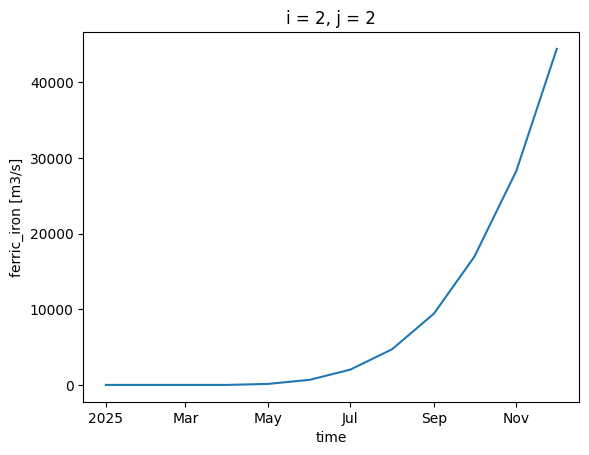

In [181]:
model.dataset["ferric_iron"].sel(i= 2, j= 2).plot()

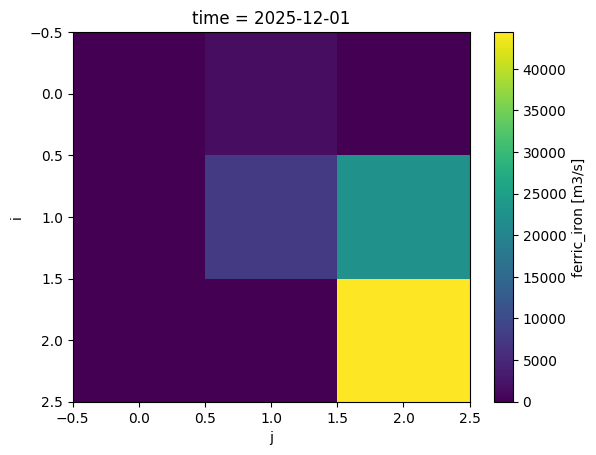

In [182]:
qm =model.dataset["ferric_iron"] \
    .sel(time="2025-12-01", method = "nearest") \
    .plot()
plt.gca().invert_yaxis()

In [183]:
sys.getsizeof(model.dataset)

120

In [195]:
ds_monthly2 = ds_monthly.copy(deep = True)
ds_monthly2["ore"].loc[dict(i=0, j=2)] = 2700

In [196]:
model2 = Model(ds_monthly2, "month")

In [197]:
model2.dataset

<xarray.Dataset> Size: 9kB
Dimensions:             (time: 12, i: 3, j: 3)
Coordinates:
  * time                (time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
  * i                   (i) int64 24B 0 1 2
  * j                   (j) int64 24B 0 1 2
    ID                  (time, i, j) int64 864B 1 2 3 4 5 6 7 ... 3 4 5 6 7 8 9
Data variables:
    Q                   (time, i, j) float64 864B 0.08333 0.1667 ... 0.25 0.5833
    outID               (time, i, j) int64 864B 2 5 6 7 6 9 8 ... 6 7 6 9 8 9 -1
    inID                (time, i, j) object 864B nan 1 nan nan ... 4 7 (6, 8)
    ore                 (time, i, j) float64 864B 2.7e+03 0.0 ... 0.0 0.0
    ferrous_iron        (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ferric_iron         (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sulphate            (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    hydrogen_ion        (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    iron_III_hydroxide  (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [198]:
model2.run()

In [199]:
model2.dataset

<xarray.Dataset> Size: 9kB
Dimensions:             (time: 12, i: 3, j: 3)
Coordinates:
  * time                (time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
  * i                   (i) int64 24B 0 1 2
  * j                   (j) int64 24B 0 1 2
    ID                  (time, i, j) int64 864B 1 2 3 4 5 6 7 ... 3 4 5 6 7 8 9
Data variables:
    Q                   (time, i, j) float64 864B 0.08333 0.1667 ... 0.25 0.5833
    outID               (time, i, j) int64 864B 2 5 6 7 6 9 8 ... 6 7 6 9 8 9 -1
    inID                (time, i, j) object 864B nan 1 nan nan ... 4 7 (6, 8)
    ore                 (time, i, j) float64 864B 2.7e+03 0.0 ... 0.0 0.0
    ferrous_iron        (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ferric_iron         (time, i, j) float64 864B 134.6 0.0 ... 0.0 1.036e+05
    sulphate            (time, i, j) float64 864B 538.3 0.0 ... 0.0 4.145e+05
    hydrogen_ion        (time, i, j) float64 864B 269.1 0.0 ... 0.0 2.19e+05
    iron_III_hydroxide  (time, i, j) float64 864B 134.6 0.0 134.6 ... 0.0 0.0

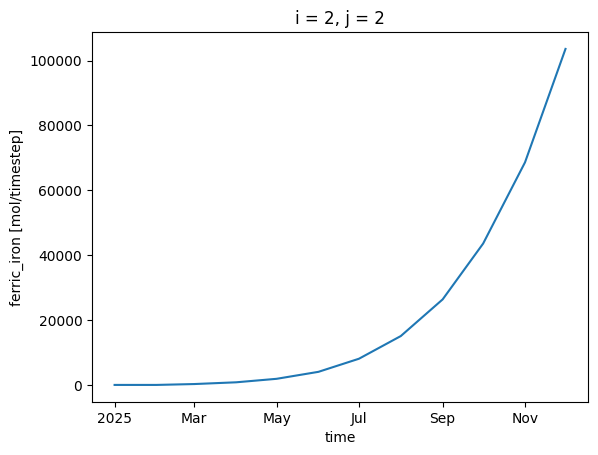

In [200]:
model2.dataset["ferric_iron"].sel(i= 2, j= 2).plot()

In [201]:
model2.output_calc()

In [202]:
model2.dataset

<xarray.Dataset> Size: 10kB
Dimensions:             (time: 12, i: 3, j: 3)
Coordinates:
  * time                (time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
  * i                   (i) int64 24B 0 1 2
  * j                   (j) int64 24B 0 1 2
    ID                  (time, i, j) int64 864B 1 2 3 4 5 6 7 ... 3 4 5 6 7 8 9
Data variables:
    Q                   (time, i, j) float64 864B 0.08333 0.1667 ... 0.25 0.5833
    outID               (time, i, j) int64 864B 2 5 6 7 6 9 8 ... 6 7 6 9 8 9 -1
    inID                (time, i, j) object 864B nan 1 nan nan ... 4 7 (6, 8)
    ore                 (time, i, j) float64 864B 2.7e+03 0.0 ... 0.0 0.0
    ferrous_iron        (time, i, j) float64 864B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ferric_iron         (time, i, j) float64 864B 3.431e-05 0.0 ... 0.0 0.003775
    sulphate            (time, i, j) float64 864B 0.0002361 0.0 ... 0.0 0.02597
    hydrogen_ion        (time, i, j) float64 864B 1.239e-06 0.0 ... 0.0 0.000144
    iron_III_hydroxide  (time, i, j) float64 864B 6.566e-05 0.0 ... 0.0 0.0
    pH                  (time, i, j) float64 864B 5.907 nan 5.907 ... nan 3.842

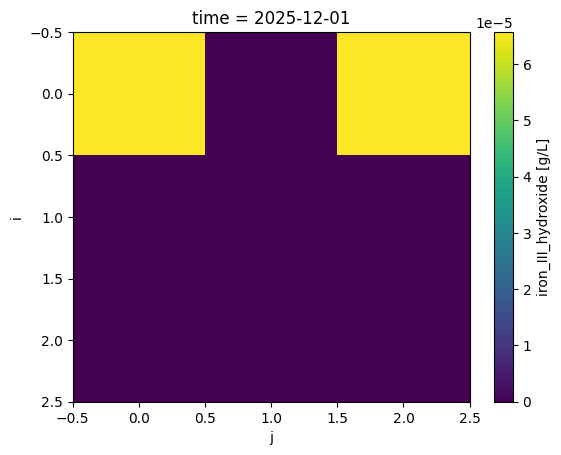

In [205]:
qm =model2.dataset["iron_III_hydroxide"] \
    .sel(time="2025-12-01", method = "nearest") \
    .plot()
plt.gca().invert_yaxis()